# Experiment: Pipeline Smoke Demo

Objective:
- Run a very small end-to-end version of the current CNN decoding pipeline on a local machine.
- Show how a subset is selected, how one layer is decoded, and what the train/test accuracy looks like.

This notebook is intentionally a small-scale sanity check, not a production analysis workflow.


In [29]:
from __future__ import annotations

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader

from EPOriGabors import EPGabors
from epgabor_v1_pipeline import (
    ConditionFilter,
    build_controlled_splits,
    evaluate_boundary_m0,
    extract_layer_features,
    fit_linear_svm,
    get_model_and_layer_map,
    list_available_layers,
    make_deterministic_transform,
    select_layer_map,
)


## Demo configuration

These defaults are intentionally conservative so the local machine can run the full walkthrough quickly.


In [ ]:
model_name = 'resnet50'
layer_name = 'stage2'
pretrained = False  # flip to True later if you want to inspect pretrained features
random_state = 0
max_features = 256
input_size = 64
device = "cpu"

config = {
    "model_name": model_name,
    "layer_name": layer_name,
    "pretrained": pretrained,
    "random_state": random_state,
    "max_features": max_features,
    "input_size": input_size,
    "device": device,
}
config


{'model_name': 'resnet50',
 'layer_name': 'stage2',
 'pretrained': True,
 'random_state': 0,
 'max_features': 256,
 'input_size': 64,
 'device': 'cpu'}

## Build a small dataset

This subset uses one set size, three SD levels, and only four instances per condition. That keeps the demo tiny while still preserving the structure of the real task.


In [31]:
transform = make_deterministic_transform(input_size=input_size)

dataset = EPGabors(
    img_dir="images",
    include_vertical=True,
    include_single=False,
    include_zerovar=False,
    filter_sd=[4, 8, 16],
    filter_ss=[4],
    filter_instance=np.arange(50).astype(int),#[1, 2, 3, 4],
    transform=transform,
    return_filename=True,
    return_condition_id=True,
)

print("Total subset size:", len(dataset))
print("Counts by mean:")
print(dataset.df.groupby("mean").size())
print()
print("Counts by sd:")
print(dataset.df.groupby("sd").size())


Total subset size: 1029
Counts by mean:
mean
-12    147
-8     147
-4     147
 0     147
 4     147
 8     147
 12    147
dtype: int64

Counts by sd:
sd
4     343
8     343
16    343
dtype: int64


## Create one explicit train/test split

Train on SD 4 and 8, and test on SD 16. Vertical-mean images (`mean=0`) are excluded from training and retained only for optional boundary inspection.


In [32]:
metadata_df = dataset.df.reset_index(drop=True).copy()
train_filter = ConditionFilter(sds=[4, 8], exclude_means=[0])
test_filter = ConditionFilter(sds=[16])
split = build_controlled_splits(
    metadata_df,
    split_mode="explicit",
    train_filter=train_filter,
    test_filter=test_filter,
)[0]

print("train_n:", int(split.train_mask.sum()))
print("test_nonzero_n:", int(split.test_nonzero_mask.sum()))
print("boundary_n:", int(split.boundary_mask.sum()))


train_n: 588
test_nonzero_n: 294
boundary_n: 49


## What the dataset contains versus what the decoder uses

- The `dataset` object contains both image tensors and condition metadata (`mean`, `sd`, `ss`, `instance`, and optional identifiers).
- The SVM is trained only on the binary target (`mean < 0` vs `mean > 0`).
- The notebook will keep the non-target variables alongside predictions so you can inspect accuracy as a function of actual stimulus conditions later.


## Instantiate the model and select one layer

The pipeline exposes stage-end layer names. We select only one of them here.


In [33]:
layer_listing = list_available_layers(model_name)
resolved = layer_listing[layer_listing["layer_name"] == layer_name].reset_index(drop=True)
display(layer_listing)

if resolved.empty:
    raise ValueError(f"Layer {layer_name!r} is not available for model {model_name!r}.")

print("Selected layer mapping:")
print(resolved.loc[0].to_dict())

model, full_layer_map = get_model_and_layer_map(
    model_name=model_name,
    pretrained=pretrained,
    device=device,
)
layer_map = select_layer_map(full_layer_map, selected_layer=layer_name)


,layer_name,module_path,module_type
0,stem,maxpool,MaxPool2d
1,stage1,layer1,Sequential
2,stage2,layer2,Sequential
3,stage3,layer3,Sequential
4,stage4,layer4,Sequential


Selected layer mapping:
{'layer_name': 'stage2', 'module_path': 'layer2', 'module_type': 'Sequential'}


## Extract one layer's features

This cell extracts pooled features for the selected layer from the entire small dataset.


In [34]:
loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)
layer_features, extracted_metadata = extract_layer_features(
    model=model,
    layer_map=layer_map,
    dataloader=loader,
    device=device,
    pooling="gap",
)

X = layer_features[layer_name]
raw_n_samples, raw_n_features = X.shape
print("Raw feature matrix shape:", X.shape)

metadata = extracted_metadata.copy()
metadata["target"] = (metadata["mean"] > 0).astype(int)
metadata.head()


Raw feature matrix shape: (1029, 512)


,mean,sd,ss,instance,file_name,condition_id,target
0,-12,4,4,1,GaborArray_m-12_sd4_ss4_1.tiff,m-12_sd4_ss4,0
1,-12,4,4,2,GaborArray_m-12_sd4_ss4_2.tiff,m-12_sd4_ss4,0
2,-12,4,4,3,GaborArray_m-12_sd4_ss4_3.tiff,m-12_sd4_ss4,0
3,-12,4,4,4,GaborArray_m-12_sd4_ss4_4.tiff,m-12_sd4_ss4,0
4,-12,4,4,5,GaborArray_m-12_sd4_ss4_5.tiff,m-12_sd4_ss4,0


## Optionally cap the number of feature dimensions

If the selected layer is high-dimensional, this keeps the demo light by using a deterministic random subset of feature columns.


In [35]:
rng = np.random.default_rng(random_state)

if raw_n_features > max_features:
    selected_columns = np.sort(rng.choice(raw_n_features, size=max_features, replace=False))
else:
    selected_columns = np.arange(raw_n_features)

X_small = X[:, selected_columns]
print("Original feature count:", raw_n_features)
print("Retained feature count:", X_small.shape[1])


Original feature count: 512
Retained feature count: 256


## Train the SVM and compute train/test accuracy

This uses the same `LinearSVC` helper as the pipeline. Training accuracy is computed manually from the fitted estimator and scaler.


In [36]:
X_train = X_small[split.train_mask]
y_train = metadata.loc[split.train_mask, "target"].to_numpy()
X_test = X_small[split.test_nonzero_mask]
y_test = metadata.loc[split.test_nonzero_mask, "target"].to_numpy()

svm_result = fit_linear_svm(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    C=1.0,
    random_state=random_state,
)

train_scaled = svm_result["scaler"].transform(X_train)
train_pred = svm_result["estimator"].predict(train_scaled)
test_pred = svm_result["y_pred"]

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_conf = confusion_matrix(y_train, train_pred, labels=[0, 1])
test_conf = confusion_matrix(y_test, test_pred, labels=[0, 1])

print("Train accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))
print()
print("Train confusion matrix [rows=true, cols=pred]:")
print(train_conf)
print()
print("Test confusion matrix [rows=true, cols=pred]:")
print(test_conf)
print()
print("Pipeline metrics on the test set:")
print(svm_result["metrics"])


Train accuracy: 1.0
Test accuracy: 0.949

Train confusion matrix [rows=true, cols=pred]:
[[294   0]
 [  0 294]]

Test confusion matrix [rows=true, cols=pred]:
[[134  13]
 [  2 145]]

Pipeline metrics on the test set:
{'balanced_accuracy': 0.9489795918367347, 'f1': 0.9508196721311475, 'confusion_matrix': [[134, 13], [2, 145]], 'auroc': 0.9941228191957056}


## Keep per-sample metadata with predictions

These result tables keep the original condition variables alongside labels, predictions, and SVM margins so you can analyze behavior by actual mean orientation, SD, set size, or instance later.


In [37]:
train_margins = svm_result["estimator"].decision_function(train_scaled)

train_results = metadata.loc[split.train_mask].copy()
train_results["pred_class"] = train_pred.astype(int)
train_results["choice_cw"] = (train_results["pred_class"] == 1).astype(int)
train_results["margin"] = train_margins.astype(float)

test_results = metadata.loc[split.test_nonzero_mask].copy()
test_results["pred_class"] = test_pred.astype(int)
test_results["choice_cw"] = (test_results["pred_class"] == 1).astype(int)
test_results["margin"] = svm_result["margins"].astype(float)

display(train_results.head())
display(test_results.head())

test_results = test_results.copy()
test_results["is_correct"] = (test_results["pred_class"] == test_results["target"]).astype(int)
mean_accuracy = test_results.groupby("mean")["is_correct"].mean().rename("accuracy").reset_index()
print("Test accuracy by actual mean orientation:")
display(mean_accuracy)


,mean,sd,ss,instance,file_name,condition_id,target,pred_class,choice_cw,margin
0,-12,4,4,1,GaborArray_m-12_sd4_ss4_1.tiff,m-12_sd4_ss4,0,0,0,-3.482094
1,-12,4,4,2,GaborArray_m-12_sd4_ss4_2.tiff,m-12_sd4_ss4,0,0,0,-3.322041
2,-12,4,4,3,GaborArray_m-12_sd4_ss4_3.tiff,m-12_sd4_ss4,0,0,0,-2.266461
3,-12,4,4,4,GaborArray_m-12_sd4_ss4_4.tiff,m-12_sd4_ss4,0,0,0,-2.562972
4,-12,4,4,5,GaborArray_m-12_sd4_ss4_5.tiff,m-12_sd4_ss4,0,0,0,-2.368670


,mean,sd,ss,instance,file_name,condition_id,target,pred_class,choice_cw,margin
98,-12,16,4,1,GaborArray_m-12_sd16_ss4_1.tiff,m-12_sd16_ss4,0,0,0,-1.228096
99,-12,16,4,2,GaborArray_m-12_sd16_ss4_2.tiff,m-12_sd16_ss4,0,0,0,-0.960547
100,-12,16,4,3,GaborArray_m-12_sd16_ss4_3.tiff,m-12_sd16_ss4,0,0,0,-1.781070
101,-12,16,4,4,GaborArray_m-12_sd16_ss4_4.tiff,m-12_sd16_ss4,0,0,0,-1.855801
102,-12,16,4,5,GaborArray_m-12_sd16_ss4_5.tiff,m-12_sd16_ss4,0,0,0,-1.588738


Test accuracy by actual mean orientation:


,mean,accuracy
0,-12,1.000000
1,-8,0.938776
2,-4,0.795918
3,4,0.979592
4,8,0.979592
5,12,1.000000


/var/folders/p0/dj81txx96fn93qhvhrcx5__00000gn/T/ipykernel_13450/1421250610.py:1: FutureWarning: The provided callable <function mean at 0x1069307c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  tmp_summary = test_results.groupby('mean').agg({'choice_cw':np.mean})


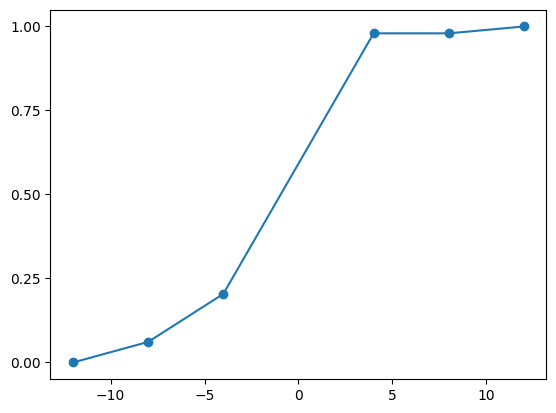

In [ ]:
tmp_summary = test_results.groupby('mean').agg({'choice_cw':np.mean})

plt.plot(tmp_summary['choice_cw'],'o-')
plt.yticks(np.arange(0,1.1,0.25))

del(tmp_summary)

## Optional: inspect vertical-mean boundary images

This is not the main target of the demo, but it shows how the current pipeline treats `mean=0` as a held-out boundary case.


In [40]:
X_boundary = X_small[split.boundary_mask]
boundary_metadata = metadata.loc[split.boundary_mask].copy()

if len(X_boundary) == 0:
    print("No boundary images were included in this split.")
else:
    boundary_trials, boundary_summary = evaluate_boundary_m0(
        estimator=svm_result["estimator"],
        scaler=svm_result["scaler"],
        X_boundary=X_boundary,
        metadata_boundary=boundary_metadata,
    )
    print("Boundary summary:")
    print(boundary_summary)
    display(boundary_trials.head())


Boundary summary:
{'boundary_n': 49.0, 'boundary_cw_rate': 0.7551020408163265, 'boundary_margin_mean': 0.3228802502348513, 'boundary_margin_std': 0.5920573745171837}


,mean,sd,ss,instance,file_name,condition_id,target,pred_class,margin,choice_cw
539,0,16,4,1,GaborArray_m0_sd16_ss4_1.tiff,m0_sd16_ss4,0,1,1.527471,1
540,0,16,4,2,GaborArray_m0_sd16_ss4_2.tiff,m0_sd16_ss4,0,1,0.478152,1
541,0,16,4,3,GaborArray_m0_sd16_ss4_3.tiff,m0_sd16_ss4,0,1,0.172816,1
542,0,16,4,4,GaborArray_m0_sd16_ss4_4.tiff,m0_sd16_ss4,0,1,0.350479,1
543,0,16,4,5,GaborArray_m0_sd16_ss4_5.tiff,m0_sd16_ss4,0,1,0.441425,1


## Interpretation

- This notebook is only a smoke test for local intuition.
- The image subset and feature dimensionality are intentionally tiny.
- For real analyses, the production pipeline should be run on a larger dataset and should save artifacts/results to disk.
- If you want a closer preview of the real analysis, the easiest next step is to increase the instance count, turn on pretrained weights, or raise `max_features`.


## Multi-layer smoke check

This section repeats the same tiny demo across all currently mapped stage-end layers for the selected model, so you can compare train/test accuracy across depth.


In [41]:
multi_model, multi_layer_map = get_model_and_layer_map(
    model_name=model_name,
    pretrained=pretrained,
    device=device,
)

all_layer_features, multi_metadata = extract_layer_features(
    model=multi_model,
    layer_map=multi_layer_map,
    dataloader=loader,
    device=device,
    pooling="gap",
)

multi_metadata = multi_metadata.copy()
multi_metadata["target"] = (multi_metadata["mean"] > 0).astype(int)
multi_layer_listing = list_available_layers(model_name).reset_index(drop=True)
multi_layer_listing


,layer_name,module_path,module_type
0,stem,maxpool,MaxPool2d
1,stage1,layer1,Sequential
2,stage2,layer2,Sequential
3,stage3,layer3,Sequential
4,stage4,layer4,Sequential


### Evaluate each layer

Each layer uses the same split masks. Feature capping is applied independently with a deterministic per-layer seed.


In [42]:
summary_rows = []

for layer_index, row in multi_layer_listing.iterrows():
    this_layer = row["layer_name"]
    X_layer = all_layer_features[this_layer]
    n_samples, n_features = X_layer.shape

    layer_rng = np.random.default_rng(random_state + layer_index)
    if n_features > max_features:
        keep_cols = np.sort(layer_rng.choice(n_features, size=max_features, replace=False))
    else:
        keep_cols = np.arange(n_features)

    X_layer_small = X_layer[:, keep_cols]
    X_train_layer = X_layer_small[split.train_mask]
    y_train_layer = multi_metadata.loc[split.train_mask, "target"].to_numpy()
    X_test_layer = X_layer_small[split.test_nonzero_mask]
    y_test_layer = multi_metadata.loc[split.test_nonzero_mask, "target"].to_numpy()

    layer_result = fit_linear_svm(
        X_train=X_train_layer,
        y_train=y_train_layer,
        X_test=X_test_layer,
        y_test=y_test_layer,
        C=1.0,
        random_state=random_state,
    )

    train_scaled_layer = layer_result["scaler"].transform(X_train_layer)
    train_pred_layer = layer_result["estimator"].predict(train_scaled_layer)

    summary_rows.append({
        "layer_name": this_layer,
        "module_path": row["module_path"],
        "train_accuracy": accuracy_score(y_train_layer, train_pred_layer),
        "test_accuracy": accuracy_score(y_test_layer, layer_result["y_pred"]),
        "n_features_raw": int(n_features),
        "n_features_used": int(len(keep_cols)),
        "test_balanced_accuracy": layer_result["metrics"]["balanced_accuracy"],
        "test_auroc": layer_result["metrics"]["auroc"],
    })

layer_summary_df = pd.DataFrame(summary_rows)
layer_summary_df = layer_summary_df.merge(
    multi_layer_listing[["layer_name", "module_path"]],
    on=["layer_name", "module_path"],
    how="left",
)
layer_summary_df


,layer_name,module_path,train_accuracy,test_accuracy,n_features_raw,n_features_used,test_balanced_accuracy,test_auroc
0,stem,maxpool,1.000000,1.000000,64,64,1.000000,1.000000
1,stage1,layer1,1.000000,1.000000,256,256,1.000000,1.000000
2,stage2,layer2,1.000000,0.959184,512,256,0.959184,0.996992
3,stage3,layer3,1.000000,0.785714,1024,256,0.785714,0.862789
4,stage4,layer4,0.770408,0.588435,2048,256,0.588435,0.632746


### Plot accuracy across layers

This is a lightweight visual summary of how linearly accessible the binary mean-orientation signal is across the currently mapped layers.


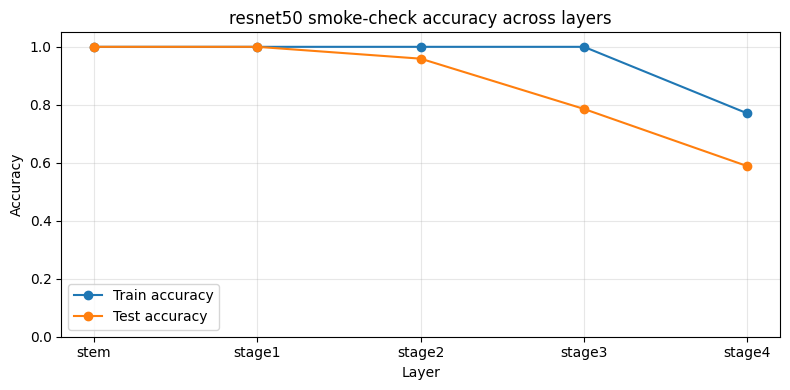

In [43]:
plot_df = layer_summary_df.copy()

plt.figure(figsize=(8, 4))
plt.plot(plot_df["layer_name"], plot_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(plot_df["layer_name"], plot_df["test_accuracy"], marker="o", label="Test accuracy")
plt.ylim(0.0, 1.05)
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title(f"{model_name} smoke-check accuracy across layers")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
